# Script to generate UMAPs colored by ERK
Use `add_erk_to_metadata.ipynb` from the apoDet repository to extract the ERK-CN for your already extracted crops 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Load metadata with ERK
df_erk = pd.read_csv("/home/nbahou/myimaging/apoDet_refactored/pao_d5_c6_metadata_w_erk.csv", index_col="Unnamed: 0")

In [4]:
# Display DF infos
df_erk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 789859 entries, 0 to 789858
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   file_path    789859 non-null  object 
 1   filename     789859 non-null  object 
 2   track_id     789859 non-null  int64  
 3   t_start      789859 non-null  int64  
 4   y_center     789859 non-null  float64
 5   x_center     789859 non-null  float64
 6   window_size  789859 non-null  int64  
 7   class        789859 non-null  object 
 8   erk_CN       789823 non-null  float64
dtypes: float64(3), int64(3), object(3)
memory usage: 60.3+ MB


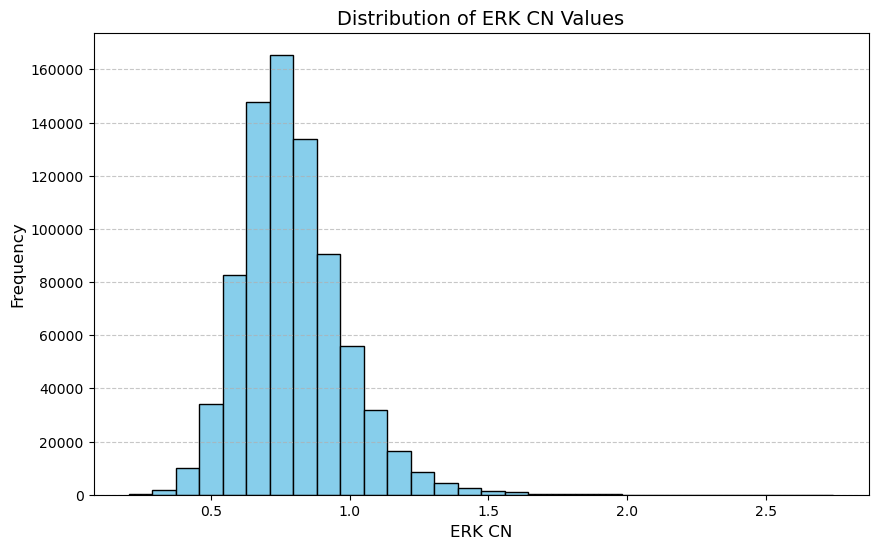

In [8]:
# Plot as sanity check
# 1. Set the visual style (optional)
plt.style.use('seaborn-v0_8-muted') 

# 2. Create the plot
plt.figure(figsize=(10, 6))
plt.hist(df_erk['erk_CN'].dropna(), bins=30, color='skyblue', edgecolor='black')

# 3. Add labels and title
plt.title('Distribution of ERK CN Values', fontsize=14)
plt.xlabel('ERK CN', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# 4. Add a grid for readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 5. Display the plot
plt.show()

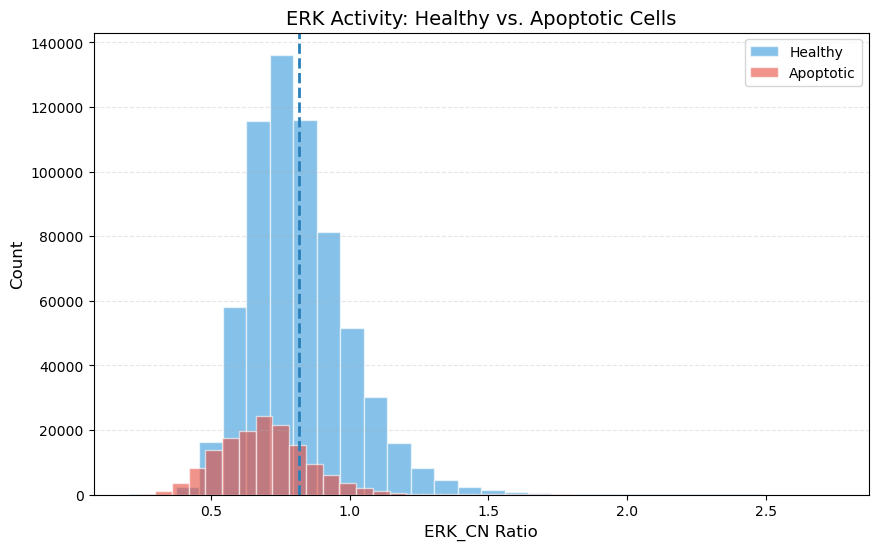

In [16]:
# show CN distributions for apoptotic and healthy cells
# 1. Separate the data based on your 'class' column
# (Adjust the strings 'apo' or 'healthy' if your labels are different)
healthy_data = df_erk[df_erk['class'] == 'no_apo']['erk_CN'].dropna()
apo_data = df_erk[df_erk['class'] == 'apo']['erk_CN'].dropna()

# 2. Create the figure
plt.figure(figsize=(10, 6))

# 3. Plot both histograms
# 'alpha' makes them transparent so you can see the overlap
plt.hist(healthy_data, bins=30, density=False, alpha=0.6, 
         label='Healthy', color='#3498db', edgecolor='white')

plt.hist(apo_data, bins=30, density=False, alpha=0.6, 
         label='Apoptotic', color='#e74c3c', edgecolor='white')

# 4. Add styling and labels
plt.title('ERK Activity: Healthy vs. Apoptotic Cells', fontsize=14)
plt.xlabel('ERK_CN Ratio', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.3)

# 5. Optional: Add a vertical line for the mean of healthy cells as a reference
plt.axvline(healthy_data.mean(), color='#2980b9', linestyle='--', linewidth=2, label='Healthy Mean')

plt.show()

In [6]:
# Rename column
df_erk['t'] = df_erk['t_start']

In [7]:
# Merge ViT feature file with ERK CN data
target_prefix = "Exp17"
merged_fragments = []
chunk_size = 200_000

# Ensure ERK keys are the right type
df_erk['track_id'] = df_erk['track_id'].astype(int)
df_erk['t'] = df_erk['t'].astype(int)

# df_erk must have a 'filename' column for the 3-key merge.
# If it doesn't exist yet, you need to construct it — e.g.:
# df_erk['filename'] = target_prefix + "_something_" + df_erk['some_col'].astype(str)
assert 'filename' in df_erk.columns, "df_erk needs a 'filename' column to merge on"

reader = pd.read_json(
    '/home/nbahou/myimaging/scDINO/pao_dat_d5_c12_features.jsonl',
    lines=True,
    chunksize=chunk_size
)

print(f"Searching for {target_prefix} data in JSONL...")

for i, chunk in enumerate(reader):
    # Pre-filter to Exp17 rows only
    chunk = chunk[chunk['filename'].str.contains(target_prefix, na=False)].copy()
    if chunk.empty:
        continue

    # Keep 't' as-is (don't rename — match your df_erk column name)
    chunk['track_id'] = chunk['track_id'].astype(int)
    chunk['t'] = chunk['t'].astype(int)

    # Merge on all 3 keys
    match = pd.merge(
        df_erk[['track_id', 't', 'filename']],
        chunk[['track_id', 't', 'filename', 'embedding']],
        on=['track_id', 't', 'filename'],
        how='inner'
    )

    if not match.empty:
        merged_fragments.append(match)

    if i % 10 == 0:
        total_lines = (i + 1) * chunk_size
        n_matches = sum(len(f) for f in merged_fragments)
        print(f"  Processed ~{total_lines:,} lines... {n_matches} matches so far.")

# Combine fragments
if merged_fragments:
    df_all_matches = pd.concat(merged_fragments, ignore_index=True)

    # Deduplicate only if you truly expect unique (track_id, t, filename) combos
    df_all_matches = df_all_matches.drop_duplicates(subset=['track_id', 't', 'filename'])

    # Final left merge to attach embeddings back to full ERK dataframe
    df_final = pd.merge(
        df_erk,
        df_all_matches[['track_id', 't', 'filename', 'embedding']],
        on=['track_id', 't', 'filename'],
        how='left'
    )

    missing = df_final['embedding'].isna().sum()
    print(f"\nDone. Rows missing embeddings: {missing:,} / {len(df_final):,}")
    if missing > 0:
        print("Sample unmatched rows:")
        print(df_final[df_final['embedding'].isna()][['track_id', 't', 'filename']].head(10))
else:
    print("No matches found.")
    print("Check: does df_erk['filename'] contain strings like those in the JSONL?")
    print("JSONL sample filenames:")
    # Quick peek at what's actually in the file
    sample = pd.read_json(
        '/home/nbahou/myimaging/scDINO/pao_dat_d5_c12_features.jsonl',
        lines=True,
        nrows=5
    )
    print(sample['filename'].tolist())

Searching for Exp17 data in JSONL...
  Processed ~200,000 lines... 34741 matches so far.
  Processed ~2,200,000 lines... 207405 matches so far.
  Processed ~4,200,000 lines... 294624 matches so far.
  Processed ~6,200,000 lines... 381815 matches so far.
  Processed ~8,200,000 lines... 469247 matches so far.
  Processed ~10,200,000 lines... 556428 matches so far.
  Processed ~12,200,000 lines... 643889 matches so far.
  Processed ~14,200,000 lines... 731188 matches so far.

Done. Rows missing embeddings: 0 / 789,859


In [8]:
# Save feature file complete with ERK CN
df_final.to_csv('feats_w_erk_exp17.csv')

In [10]:
df_final

,file_path,filename,track_id,t_start,y_center,x_center,window_size,class,erk_CN,t,embedding
0,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site01,655,230,200.0,64.0,32,apo,0.695070,230,"[2.5387752056, -0.09096126260000001, -2.810480..."
1,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site01,655,232,200.0,62.0,32,apo,0.716507,232,"[2.8020281792, 1.2830123901000001, -1.97352385..."
2,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site01,655,233,200.0,62.0,32,apo,0.717775,233,"[3.5026211739, 0.2455821186, -1.89488172529999..."
3,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site01,655,235,198.0,62.0,32,apo,0.719131,235,"[3.1474545002, 0.2051223218, -2.1481404305, -1..."
4,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site01,655,237,200.0,62.0,32,apo,0.713556,237,"[3.0945327282, 1.6813346148, -1.8787477016, -2..."
...,...,...,...,...,...,...,...,...,...,...,...
789854,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site08,5269,1421,798.0,382.0,32,no_apo,0.754756,1421,"[-4.8228335381, -2.3671228886, -0.080750145000..."
789855,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site08,5269,1422,798.0,382.0,32,no_apo,0.781431,1422,"[-5.2910561562, -1.519996047, 0.10837189850000..."
789856,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site08,5269,1423,798.0,382.0,32,no_apo,0.806650,1423,"[-4.8236069679, -1.6201653481, 0.0944782123, 0..."
789857,/mnt/imaging.data/nbahou/apoDet_refactored/dat...,Exp17_Site08,5269,1424,798.0,382.0,32,no_apo,0.831015,1424,"[-4.6451349258, -2.2294876575, -0.1526352018, ..."


Converting embeddings for 78986 cells...
Using GPU-accelerated UMAP (cuML)
[2026-03-31 15:04:46.838] [CUML] [info] build_algo set to brute_force_knn because random_state is given
Running UMAP on (78986, 384) matrix...


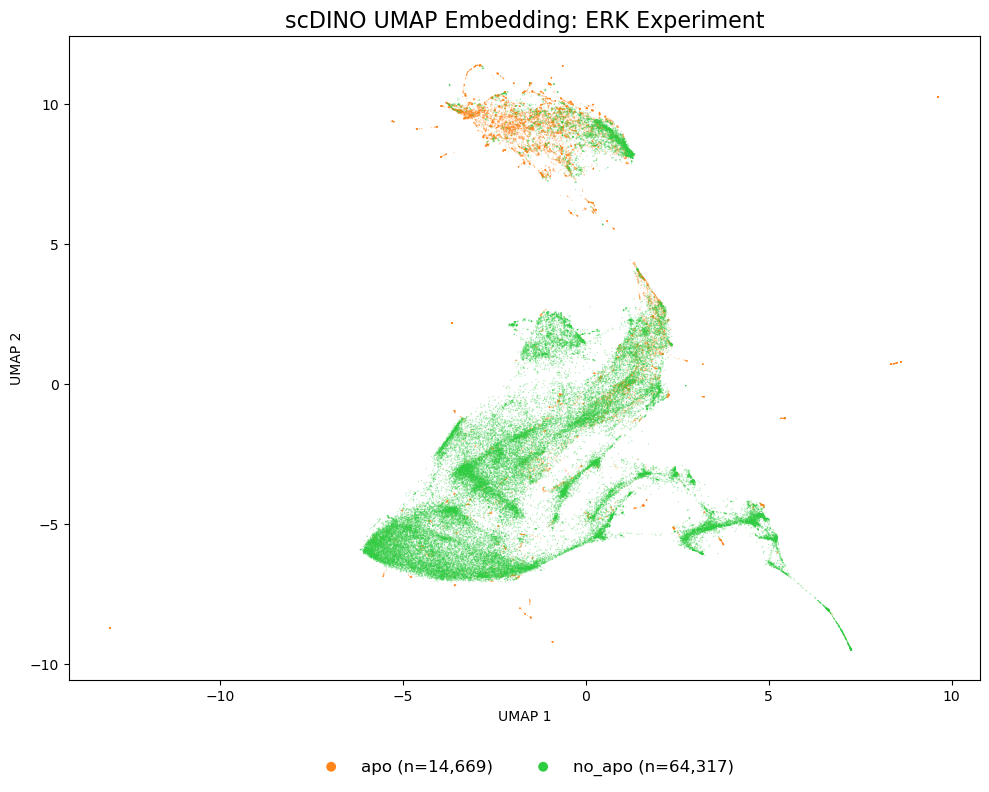

In [18]:
# Create UMAP colored by apo status
# ── 1. Prepare Data ───────────────────────────────────────────────────────────
# UMAP cannot handle NaNs. We must drop rows that didn't get an embedding.
df_plot = df_final.dropna(subset=['embedding']).copy()
df_plot = df_final.sample(frac=0.1, random_state=42)

# Convert the column of lists into a 2D NumPy array (N, D)
print(f"Converting embeddings for {len(df_plot)} cells...")
feats = np.stack(df_plot['embedding'].values)

# Map your 'class' names to match the color_map in your template
# If your non-apoptotic cells are labeled 'healthy', we'll rename them to 'no_apo'
df_plot['apo_label'] = df_plot['class'].replace({'healthy': 'no_apo'})

# ── 2. Run UMAP (GPU/CPU Fallback) ─────────────────────────────────────────────
try:
    from cuml import UMAP as GPU_UMAP
    use_gpu = True
    print("Using GPU-accelerated UMAP (cuML)")
except ImportError:
    from umap import UMAP as CPU_UMAP
    use_gpu = False
    print("cuML not found, falling back to CPU UMAP")

UMAP_Class = GPU_UMAP if use_gpu else CPU_UMAP

reducer = UMAP_Class(
    n_components=2,
    n_neighbors=100,
    min_dist=0.0,
    metric="cosine",
    random_state=42,
    init="spectral",
    n_epochs=750,
)

print(f"Running UMAP on {feats.shape} matrix...")
embedding = reducer.fit_transform(feats)

df_plot['x'] = embedding[:, 0]
df_plot['y'] = embedding[:, 1]

# ── 3. Plot ────────────────────────────────────────────────────────────────────
COLOR_BY = 'apo_label'

color_map = {
    'apo':        '#FF851B', # Orange
    'no_apo':     '#2ECC40', # Green
    'wt':         '#4A90E2', # Blue
    'pik_h1047r': '#9B59B6', # Purple
    'unknown':    '#AAAAAA', # Grey
}

point_size = 0.75

fig, ax = plt.subplots(figsize=(10, 8))

# Sort so the smaller population (usually 'apo') is plotted on top
counts = df_plot[COLOR_BY].value_counts()
sorted_labels = counts.index.tolist()[::-1] 

for label in sorted_labels:
    group = df_plot[df_plot[COLOR_BY] == label]
    ax.scatter(
        group['x'],
        group['y'],
        label=f"{label} (n={len(group):,})",
        s=point_size,
        alpha=0.4, # Slightly higher alpha for visibility
        c=color_map.get(label, 'grey'),
        edgecolors='none',
    )

ax.set_title("scDINO UMAP Embedding: ERK Experiment", fontsize=16)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

leg = ax.legend(
    loc='upper center',
    bbox_to_anchor=(0.5, -0.1),
    ncol=4,
    frameon=False,
    fontsize=12,
)

for handle in leg.legend_handles:
    handle.set_sizes([50.0])
    handle.set_alpha(1.0)

plt.tight_layout()
plt.show()

In [51]:
# Calculate log 2 erk CN
df_plot['log2_erk_CN'] = np.log2(df_plot['erk_CN'] + 1e-6)

In [78]:
# Save data
df_plot.to_csv("feats_w_erk_exp17_umap_100_00_79k.csv")

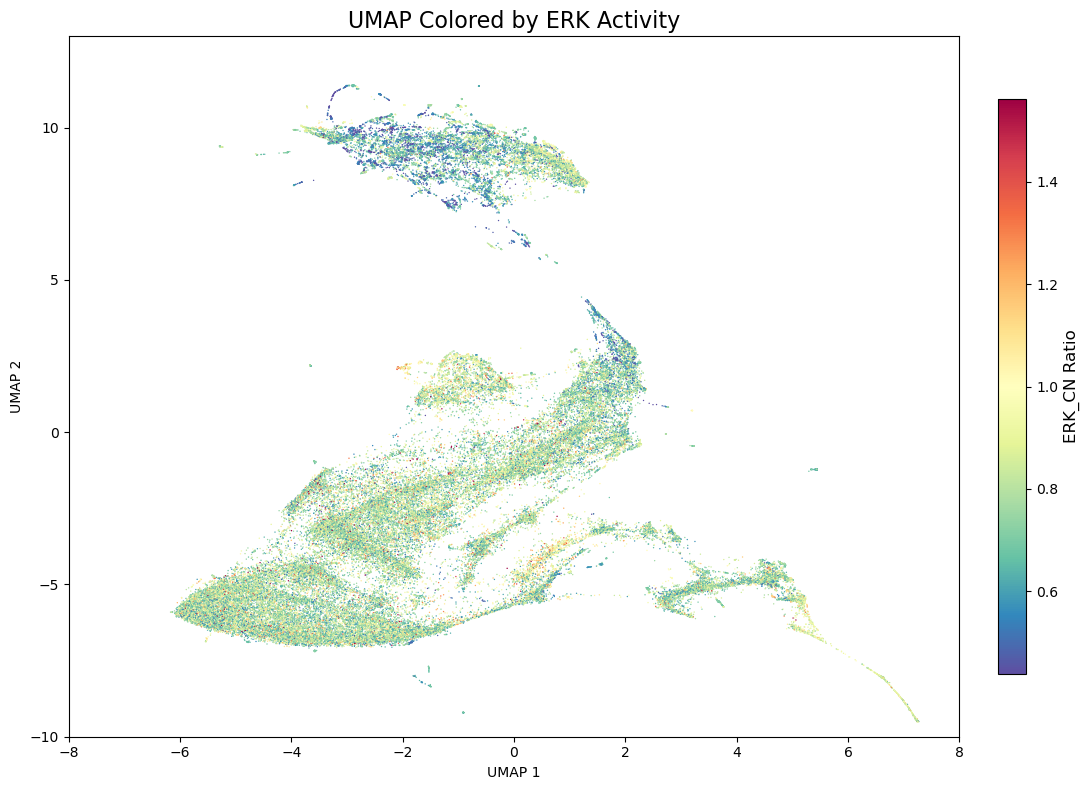

In [77]:
# Create UMAP colored by ERK
# ── 3. Plot by ERK_CN Intensity ───────────────────────────────────────────────
point_size = 1.0  # Slightly smaller often looks better for continuous gradients
alpha_val = 1.0

color_by_col = df_plot['erk_CN']

fig, ax = plt.subplots(figsize=(11, 8)) # Wider to accommodate colorbar

# We plot all points at once to apply the gradient
scatter = ax.scatter(
    df_plot['x'],
    df_plot['y'],
    c= color_by_col, #df_plot['erk_CN'],    # Color determined by ERK values
    cmap='Spectral_r',           # 'magma', 'viridis', or 'plasma' are great managua_r
    s=point_size,
    alpha=alpha_val,
    edgecolors='none',
    rasterized=True,
)

# Add a colorbar to show what the colors mean
cbar = plt.colorbar(scatter, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label('ERK_CN Ratio', fontsize=12)

ax.set_title("UMAP Colored by ERK Activity", fontsize=16)
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")

ax.set_xlim(-8, 8)
ax.set_ylim(-10, 13)

# Optional: Set a specific range for the colorbar to ignore extreme outliers
#scatter.set_clim(0.25, 1.5) 
# Calculate robust limits
low = np.percentile(color_by_col.dropna(), 1)
high = np.percentile(color_by_col.dropna(), 99)

# Use the larger of the two absolute values to keep the colorbar centered at 0
v_limit = max(1-abs(low), 1-abs(high))

scatter.set_clim(1-v_limit, 1+v_limit)
#scatter.set_clim(low, high)

plt.tight_layout()
plt.savefig("UMAP_ERK_Activity_spectral_r.svg", format='svg', bbox_inches='tight')
plt.show()